In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import sklearn.datasets
from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KDTree

from keras.datasets import cifar10
from keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.datasets import mnist


In [2]:
def KNN_Classify(x_train,Y_train,inpus):
    Ans = []
    n = len(x_train)
    filteTrain = [np.random.randint(0,x_train.shape[0],min(40000,int(n/1)))]
    X_train = x_train[filteTrain]
    y_train = Y_train[filteTrain]
    tree = KDTree(X_train)
    distances, indices = tree.query(inpus, k=min(700,int(n/3)))
    print("treed")
    t = 0
    for ii in range(len(inpus)):  
        inpu = inpus[ii]
        dis = distances[ii]
        bias = y_train.mean(axis=0)
        bb = bias.mean()
        k = 2*np.pi
        bias-=bb
        DD = ((1/np.e**(k*dis).reshape(-1,1))).sum()
        print(DD)
        print(t,"________________",t,flush=True)
        t+=1
        Ans.append((((y_train[indices[ii]])/(np.e**(k*dis).reshape(-1,1))).sum(axis=0)/DD)-bias)
    return Ans

## logistic based
def KNN_Classify(x_train,Y_train,inpus):
    Ans = []
    n = len(x_train)
    filteTrain = [np.random.randint(0,x_train.shape[0],min(40000,int(n/1)))]
    X_train = x_train[filteTrain]
    y_train = Y_train[filteTrain]
    tree = KDTree(X_train)
    distances, indices = tree.query(inpus, k=min(700,int(n/3)))
    print("treed")
    t = 0
    for ii in range(len(inpus)):  
        inpu = inpus[ii]
        dis = distances[ii]
        bias = y_train.mean(axis=0)
        bb = bias.mean()
        k = 2*np.pi
        bias-=bb
        DD = ((1/(np.e**(k*dis)+1).reshape(-1,1))).sum()
        print(DD)
        print(t,"________________",t,flush=True)
        t+=1
        Ans.append((((y_train[indices[ii]])/((np.e**(k*dis)+1).reshape(-1,1))).sum(axis=0)/DD)-bias)
    return Ans



# The Algorithm

The algorithm is similar to KNN, but instead of taking the discrete values of classes and averaging them, they are
averaged by weighted by the distance it is from the point of interst.. Simple weighted average based on distance does not provide the best result so the weight is distance passed through a sigmoid/exponential function.. Taking all the points in the training data is irrelavant as the weight value decreases with increasing distance so instead some nearby points are considered.. the number of such points under considered is currently arbitary but it depends on the density of points in the training data.

## The steps::

Consider the input X, we find k nearest points to X in the training data

Let $$d_1,d_2,d_3,d_4..d_k$$ be the distances and $$y_1,y_2,y_3,y_4..y_k$$ be the distances and respective classes of the training data points, respectively.



We take a function f(x) (=e^(-x), or logistic function(works better)).. that converts distances to weights for averaging..



We find $$
y_\pred = (\Sigma f(d_i)*y_i)/(\Sigma f(d_i))
$$

This is the prediction of the input data

In [3]:
## Loading MNIST DATASET

(x_train, Y_train), (x_test, Y_test) = mnist.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0
x_train = x_train.reshape(60000,-1)
Y_train = Y_train.reshape(60000,1)
Y_train = to_categorical(Y_train)
x_test = x_test.reshape(10000,-1)
Y_test = Y_test.reshape(10000,1)
Y_test = to_categorical(Y_test)

In [4]:
## Predicting the Classes for the Test Set

filteTest = [np.random.randint(0,x_test.shape[0],1000)]
X_test = x_test[filteTest]
y_test = Y_test[filteTest]
y_pred = np.array(KNN_Classify(x_train,Y_train,X_test))

/var/folders/4q/kbjf5khx03n2wv_vdztf96480000gn/T/ipykernel_2010/634040744.py:4: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  X_test = x_test[filteTest]
/var/folders/4q/kbjf5khx03n2wv_vdztf96480000gn/T/ipykernel_2010/634040744.py:5: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  y_test = Y_test[filteTest]
/var/folders/4q/kbjf5khx03n2wv_vdztf96480000gn/T/ipykernel_2010/884647241.py:30: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will b

treed
2.468856955770055e-13
0 ________________ 0
1.1358356009103248e-10
1 ________________ 1
4.12722476101787e-14
2 ________________ 2
1.0550007998135082e-12
3 ________________ 3
1.720786536018838e-15
4 ________________ 4
4.915870106239753e-21
5 ________________ 5
1.889587143444976e-16
6 ________________ 6
1.2632483482440855e-11
7 ________________ 7
1.7608569703635544e-12
8 ________________ 8
9.8046947082249e-12
9 ________________ 9
3.385634336171076e-14
10 ________________ 10
1.1524258263907674e-13
11 ________________ 11
0.00014430561796820063
12 ________________ 12
0.0001159774038954424
13 ________________ 13
8.364614827655899e-09
14 ________________ 14
0.0003463618097479473
15 ________________ 15
2.4339290251664556e-13
16 ________________ 16
4.002488670870766e-12
17 ________________ 17
8.080059174397942e-14
18 ________________ 18
6.099786588254682e-09
19 ________________ 19
4.873388702688739e-12
20 ________________ 20
7.962974216053529e-16
21 ________________ 21
2.5235640364790557e-

2.11098648809696e-11
178 ________________ 178
4.2893040421830155e-09
179 ________________ 179
5.6030771160375646e-05
180 ________________ 180
2.8993570683273792e-05
181 ________________ 181
7.335237580880095e-15
182 ________________ 182
7.383773466884511e-11
183 ________________ 183
1.2296808843034403e-11
184 ________________ 184
9.84178652109288e-12
185 ________________ 185
2.1769645364433323e-11
186 ________________ 186
1.2194662477334605e-08
187 ________________ 187
9.420943517374218e-13
188 ________________ 188
1.3047297834253611e-12
189 ________________ 189
2.1735511035876804e-16
190 ________________ 190
5.615517654674261e-12
191 ________________ 191
7.767547949123878e-13
192 ________________ 192
1.176990572435156e-13
193 ________________ 193
3.653332208779696e-11
194 ________________ 194
2.369964364188198e-16
195 ________________ 195
4.039741178281336e-16
196 ________________ 196
9.212970787244677e-16
197 ________________ 197
4.6386769387370894e-11
198 ________________ 198
1.6022

6.3339129328502115e-12
352 ________________ 352
2.2060036646989502e-13
353 ________________ 353
5.88690759501468e-13
354 ________________ 354
2.226089751555432e-12
355 ________________ 355
1.0206254315720131e-13
356 ________________ 356
2.6845321712661445e-13
357 ________________ 357
9.843939560572211e-13
358 ________________ 358
2.4717193642772563e-17
359 ________________ 359
0.001552663232891605
360 ________________ 360
2.5845951906668847e-13
361 ________________ 361
7.159340376323981e-14
362 ________________ 362
0.00047164048778784446
363 ________________ 363
2.5258948939760666e-10
364 ________________ 364
4.916410680709465e-05
365 ________________ 365
6.4325130706161445e-12
366 ________________ 366
1.592214703317416e-17
367 ________________ 367
8.124413364617844e-14
368 ________________ 368
1.3298272736665472e-13
369 ________________ 369
6.964247681160444e-15
370 ________________ 370
1.180366074333938e-13
371 ________________ 371
2.1459459318674096e-12
372 ________________ 372
5.70

1.0260384750940871e-17
525 ________________ 525
8.732622224106819e-09
526 ________________ 526
3.863147264518757e-11
527 ________________ 527
2.424941574100986e-12
528 ________________ 528
5.486170531312167e-11
529 ________________ 529
1.9725832032977406e-05
530 ________________ 530
1.2045199823104115e-11
531 ________________ 531
2.118989418013664e-13
532 ________________ 532
8.027818999474269e-13
533 ________________ 533
6.840835183269538e-13
534 ________________ 534
1.434876956696811e-05
535 ________________ 535
3.149000552456305e-10
536 ________________ 536
1.4895924027126484e-09
537 ________________ 537
3.5356069892882363e-10
538 ________________ 538
6.537400113195571e-11
539 ________________ 539
5.073112417265061e-06
540 ________________ 540
4.9081469764636195e-11
541 ________________ 541
2.941031019500987e-16
542 ________________ 542
8.33975797899322e-11
543 ________________ 543
1.0124676937138637e-13
544 ________________ 544
9.190521694331342e-09
545 ________________ 545
4.70020

3.377252963698178e-13
699 ________________ 699
1.4681599255729548e-13
700 ________________ 700
1.9489678513378353e-10
701 ________________ 701
3.635150927227085e-16
702 ________________ 702
1.8602455991727396e-16
703 ________________ 703
3.516763162503363e-13
704 ________________ 704
1.1591136049375934e-13
705 ________________ 705
8.092716305118993e-12
706 ________________ 706
5.1733833873017834e-17
707 ________________ 707
6.780979257433286e-14
708 ________________ 708
4.148778460020221e-14
709 ________________ 709
2.1516267950367972e-16
710 ________________ 710
0.00015592363523534393
711 ________________ 711
1.8814796983512215e-13
712 ________________ 712
2.665075638852506e-14
713 ________________ 713
2.9213891992629796e-15
714 ________________ 714
5.733199735673197e-16
715 ________________ 715
2.4701902201631735e-15
716 ________________ 716
6.892550206735422e-19
717 ________________ 717
1.825057512246575e-10
718 ________________ 718
5.401760496821338e-11
719 ________________ 719
6.8

6.712100082905481e-16
872 ________________ 872
1.1114503924486972e-10
873 ________________ 873
6.0433528223829195e-05
874 ________________ 874
7.72806405872092e-18
875 ________________ 875
1.3680043601276225e-05
876 ________________ 876
8.345985792314729e-13
877 ________________ 877
7.057169975254101e-13
878 ________________ 878
5.554375761669252e-18
879 ________________ 879
1.0931957080944464e-15
880 ________________ 880
4.761204845462281e-06
881 ________________ 881
0.00019729303759827708
882 ________________ 882
4.228722825088732e-15
883 ________________ 883
0.0004967549972267467
884 ________________ 884
2.845182767571729e-09
885 ________________ 885
3.44501290100409e-11
886 ________________ 886
4.521177739485753e-16
887 ________________ 887
1.19325809204206e-13
888 ________________ 888
1.1865016223433754e-14
889 ________________ 889
1.7053372353966365e-11
890 ________________ 890
1.1513681952260856e-14
891 ________________ 891
6.21782522956134e-13
892 ________________ 892
1.0550007

In [5]:
## Checking Accuracy
n = len(y_test)
acc = sum([np.argmax(y_test[i])==np.argmax(y_pred[i]) for i in range(n)])/n
ind = np.arange(0,n)
print("The Accuracy for this test set")
acc

The Accuracy for this test set


0.956

In [6]:
### Testing on a different dataset

X, Y = sklearn.datasets.load_iris(return_X_y=True)
x_train,x_test,Y_train,Y_test = train_test_split(X,Y)
Y_train = to_categorical(Y_train)
Y_test = to_categorical(Y_test)

In [7]:
## Predicting the Classes for the Test Set

filteTest = [np.random.randint(0,x_test.shape[0],3000)]
X_test = x_test[filteTest]
y_test = Y_test[filteTest]
y_pred = np.array(KNN_Classify(x_train,Y_train,X_test))

treed
0.6915744818454177
0 ________________ 0
0.5218520477309307
1 ________________ 1
0.6681870539999444
2 ________________ 2
0.5294566481072812
3 ________________ 3
3.1465401470483543
4 ________________ 4
0.14288564717831037
5 ________________ 5
1.4477393081483327
6 ________________ 6
0.21342255895593115
7 ________________ 7
3.0607787810052773
8 ________________ 8
1.9669547800060443
9 ________________ 9
2.8404581371535733
10 ________________ 10
0.14288564717831037
11 ________________ 11
2.8404581371535733
12 ________________ 12
3.846811795276968
13 ________________ 13
2.8404581371535733
14 ________________ 14
2.601921640894487
15 ________________ 15
1.333614988160203
16 ________________ 16
0.21342255895593115
17 ________________ 17
0.05906040117057659
18 ________________ 18
0.37060053058179176
19 ________________ 19
3.2028680259692295
20 ________________ 20
0.5218520477309307
21 ________________ 21
0.37060053058179176
22 ________________ 22
1.6050285228494625
23 ________________ 23
1.

1.2742251389419883
192 ________________ 192
0.2856321306340416
193 ________________ 193
0.5294566481072812
194 ________________ 194
1.6521253936391695
195 ________________ 195
3.1465401470483543
196 ________________ 196
3.846811795276968
197 ________________ 197
0.5294566481072812
198 ________________ 198
1.9669547800060443
199 ________________ 199
1.4477393081483327
200 ________________ 200
1.333614988160203
201 ________________ 201
3.2028680259692295
202 ________________ 202
1.4232673409513688
203 ________________ 203
0.2856321306340416
204 ________________ 204
0.01597445960111018
205 ________________ 205
0.5301648508189324
206 ________________ 206
0.5301648508189324
207 ________________ 207
0.01597445960111018
208 ________________ 208
0.6915744818454177
209 ________________ 209
0.44455687145265954
210 ________________ 210
1.33530804652826
211 ________________ 211
1.6050285228494625
212 ________________ 212
0.01597445960111018
213 ________________ 213
0.01597445960111018
214 ________

3.2028680259692295
379 ________________ 379
1.4232673409513688
380 ________________ 380
1.2742251389419883
381 ________________ 381
3.846811795276968
382 ________________ 382
0.13857520772797974
383 ________________ 383
1.8474740780581624
384 ________________ 384
1.33530804652826
385 ________________ 385
1.8474740780581624
386 ________________ 386
0.4968597420814693
387 ________________ 387
1.333614988160203
388 ________________ 388
1.8474740780581624
389 ________________ 389
1.6521253936391695
390 ________________ 390
0.05906040117057659
391 ________________ 391
0.01597445960111018
392 ________________ 392
0.44455687145265954
393 ________________ 393
1.9669547800060443
394 ________________ 394
3.846811795276968
395 ________________ 395
0.6915744818454177
396 ________________ 396
0.05906040117057659
397 ________________ 397
3.0607787810052773
398 ________________ 398
0.37060053058179176
399 ________________ 399
0.5090831835485006
400 ________________ 400
0.5090831835485006
401 ________

0.5913907413695635
565 ________________ 565
1.6050285228494625
566 ________________ 566
3.846811795276968
567 ________________ 567
0.05906040117057659
568 ________________ 568
0.4968597420814693
569 ________________ 569
1.3503719495513886
570 ________________ 570
0.5294566481072812
571 ________________ 571
1.2742251389419883
572 ________________ 572
0.5218520477309307
573 ________________ 573
0.21342255895593115
574 ________________ 574
0.5301648508189324
575 ________________ 575
0.44455687145265954
576 ________________ 576
0.5913907413695635
577 ________________ 577
0.5090831835485006
578 ________________ 578
0.1759804827113307
579 ________________ 579
0.14288564717831037
580 ________________ 580
0.5301648508189324
581 ________________ 581
0.44455687145265954
582 ________________ 582
0.2856321306340416
583 ________________ 583
3.846811795276968
584 ________________ 584
0.5294566481072812
585 ________________ 585
1.4477393081483327
586 ________________ 586
0.1759804827113307
587 ______

/var/folders/4q/kbjf5khx03n2wv_vdztf96480000gn/T/ipykernel_2010/375366174.py:4: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  X_test = x_test[filteTest]
/var/folders/4q/kbjf5khx03n2wv_vdztf96480000gn/T/ipykernel_2010/375366174.py:5: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  y_test = Y_test[filteTest]
/var/folders/4q/kbjf5khx03n2wv_vdztf96480000gn/T/ipykernel_2010/884647241.py:30: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will b

...

1.3503719495513886
2242 ________________ 2242
0.4009238906649509
2243 ________________ 2243
0.05906040117057659
2244 ________________ 2244
0.2856321306340416
2245 ________________ 2245
1.4232673409513688
2246 ________________ 2246
0.5218520477309307
2247 ________________ 2247
1.8474740780581624
2248 ________________ 2248
0.0789397584883989
2249 ________________ 2249
0.4009238906649509
2250 ________________ 2250
1.4232673409513688
2251 ________________ 2251
3.846811795276968
2252 ________________ 2252
0.2856321306340416
2253 ________________ 2253
1.333614988160203
2254 ________________ 2254
1.2869266258432202
2255 ________________ 2255
0.0789397584883989
2256 ________________ 2256
0.5913907413695635
2257 ________________ 2257
1.2742251389419883
2258 ________________ 2258
0.14288564717831037
2259 ________________ 2259
1.2742251389419883
2260 ________________ 2260
0.14288564717831037
2261 ________________ 2261
0.14288564717831037
2262 ________________ 2262
0.8392312952137234
2263 ________

0.01597445960111018
2420 ________________ 2420
1.333614988160203
2421 ________________ 2421
1.6050285228494625
2422 ________________ 2422
0.5218520477309307
2423 ________________ 2423
1.4477393081483327
2424 ________________ 2424
0.1759804827113307
2425 ________________ 2425
1.2869266258432202
2426 ________________ 2426
0.2856321306340416
2427 ________________ 2427
1.4477393081483327
2428 ________________ 2428
3.0607787810052773
2429 ________________ 2429
0.4968597420814693
2430 ________________ 2430
0.5294566481072812
2431 ________________ 2431
0.5301648508189324
2432 ________________ 2432
1.4232673409513688
2433 ________________ 2433
0.37060053058179176
2434 ________________ 2434
0.4009238906649509
2435 ________________ 2435
1.6050285228494625
2436 ________________ 2436
3.0607787810052773
2437 ________________ 2437
1.3503719495513886
2438 ________________ 2438
0.5301648508189324
2439 ________________ 2439
3.846811795276968
2440 ________________ 2440
0.44455687145265954
2441 _________

0.1759804827113307
2598 ________________ 2598
1.8474740780581624
2599 ________________ 2599
0.5913907413695635
2600 ________________ 2600
1.6521253936391695
2601 ________________ 2601
0.8392312952137234
2602 ________________ 2602
0.13857520772797974
2603 ________________ 2603
1.2742251389419883
2604 ________________ 2604
1.8474740780581624
2605 ________________ 2605
0.5090831835485006
2606 ________________ 2606
2.601921640894487
2607 ________________ 2607
0.0789397584883989
2608 ________________ 2608
0.44455687145265954
2609 ________________ 2609
1.6050285228494625
2610 ________________ 2610
0.21342255895593115
2611 ________________ 2611
0.2856321306340416
2612 ________________ 2612
1.4232673409513688
2613 ________________ 2613
1.3503719495513886
2614 ________________ 2614
0.5301648508189324
2615 ________________ 2615
0.4009238906649509
2616 ________________ 2616
1.3503719495513886
2617 ________________ 2617
0.44455687145265954
2618 ________________ 2618
0.5301648508189324
2619 _______

1.2742251389419883
2776 ________________ 2776
0.2856321306340416
2777 ________________ 2777
1.4232673409513688
2778 ________________ 2778
3.1465401470483543
2779 ________________ 2779
1.2869266258432202
2780 ________________ 2780
1.8474740780581624
2781 ________________ 2781
1.8474740780581624
2782 ________________ 2782
1.3503719495513886
2783 ________________ 2783
0.4009238906649509
2784 ________________ 2784
3.0607787810052773
2785 ________________ 2785
3.2028680259692295
2786 ________________ 2786
0.5294566481072812
2787 ________________ 2787
1.3503719495513886
2788 ________________ 2788
0.6681870539999444
2789 ________________ 2789
0.44455687145265954
2790 ________________ 2790
3.846811795276968
2791 ________________ 2791
0.1759804827113307
2792 ________________ 2792
1.6521253936391695
2793 ________________ 2793
1.9669547800060443
2794 ________________ 2794
3.2028680259692295
2795 ________________ 2795
1.2869266258432202
2796 ________________ 2796
1.4232673409513688
2797 __________

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)



In [8]:
## Checking Accuracy
n = len(y_test)
acc = sum([np.argmax(y_test[i])==np.argmax(y_pred[i]) for i in range(n)])/n
#acc = 1 - sum([abs((y_test[i])-(y_pred[i])) for i in range(n)])/n

print("The Accuracy for this test set")
acc

The Accuracy for this test set


0.9646666666666667

In [9]:
### Testing on a different dataset

data = sklearn.datasets.fetch_openml("diabetes", version=1, as_frame=True, return_X_y=False)
X = np.array(data["data"])
Y = np.where(data["target"]=="tested_positive",0,1)#np.array(list(map(list(data["target"]),lambda x: 1 if x == "tested_positive" else 0)))
x_train,x_test,Y_train,Y_test = train_test_split(X,Y)
Y_train = to_categorical(Y_train)
Y_test = to_categorical(Y_test)


/Users/samarthpusalkar/miniconda3/envs/AI/lib/python3.8/site-packages/sklearn/datasets/_openml.py:932: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


In [10]:
## Predicting the Classes for the Test Set

filteTest = [np.random.randint(0,x_test.shape[0],3000)]
X_test = x_test#[filteTest]
y_test = Y_test#[filteTest]
y_pred = np.array(KNN_Classify(x_train,Y_train,X_test))

treed
2.0957979145608845e-20
0 ________________ 0
4.48469437690722e-43
1 ________________ 1
1.0523425371499286e-32
2 ________________ 2
1.7309351671301717e-64
3 ________________ 3
5.258586588177199e-37
4 ________________ 4
1.4699421316486203e-39
5 ________________ 5
5.202588452269268e-90
6 ________________ 6
6.679968836703091e-16
7 ________________ 7
5.7077376288012276e-42
8 ________________ 8
5.373905809076216e-57
9 ________________ 9
1.1215440100964547e-37
10 ________________ 10
9.533950791059697e-33
11 ________________ 11
1.3253397149224647e-23
12 ________________ 12
4.924650571453616e-26
13 ________________ 13
8.972937595031948e-63
14 ________________ 14
5.319391890746529e-39
15 ________________ 15
7.513305726966925e-79
16 ________________ 16
2.2646462839421545e-20
17 ________________ 17
4.705973311704745e-37
18 ________________ 18
6.83720369787365e-51
19 ________________ 19
5.3934303036244e-22
20 ________________ 20
1.7741578768752914e-37
21 ________________ 21
1.0964965552683413e

2.84704241231313e-44
178 ________________ 178
1.5643877649598277e-28
179 ________________ 179
1.8707374432821506e-15
180 ________________ 180
5.71242781536709e-31
181 ________________ 181
1.0523868355292628e-31
182 ________________ 182
5.598635656268872e-63
183 ________________ 183
6.08388048308609e-38
184 ________________ 184
6.6512149964573e-24
185 ________________ 185
2.134296168203594e-38
186 ________________ 186
3.125801186928536e-38
187 ________________ 187
7.214079439589618e-82
188 ________________ 188
5.292114631415178e-67
189 ________________ 189
1.459045805135809e-42
190 ________________ 190
6.254148576129369e-43
191 ________________ 191


/var/folders/4q/kbjf5khx03n2wv_vdztf96480000gn/T/ipykernel_2010/884647241.py:30: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  X_train = x_train[filteTrain]
/var/folders/4q/kbjf5khx03n2wv_vdztf96480000gn/T/ipykernel_2010/884647241.py:31: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  y_train = Y_train[filteTrain]
/var/folders/4q/kbjf5khx03n2wv_vdztf96480000gn/T/ipykernel_2010/884647241.py:43: RuntimeWarning: overflow encountered in power
  DD = ((1/(np.e**(k*dis)+1).reshape(-1,1))).sum()
/var/folders/4q/kbjf5khx03n2wv_vdztf96480000gn/T/ipy

In [11]:
## Checking Accuracy
n = len(y_test)
acc = sum([np.argmax(y_test[i])==np.argmax(y_pred[i]) for i in range(n)])/n
#acc = 1 - sum([abs((y_test[i])-(y_pred[i])) for i in range(n)])/n

print("The Accuracy for this test set")
acc

The Accuracy for this test set


0.6927083333333334

In [12]:
### Testing on a different dataset

X, Y = sklearn.datasets.fetch_openml("titanic", return_X_y=True, as_frame=False)
Y = (np.array(list(map(int,Y)))+1)/2
#X = np.array(data["data"])
#Y = np.where(data["target"]=="tested_positive",0,1)#np.array(list(map(list(data["target"]),lambda x: 1 if x == "tested_positive" else 0)))
x_train,x_test,Y_train,Y_test = train_test_split(X,Y)
Y_train = to_categorical(Y_train)
Y_test = to_categorical(Y_test)
x_train

/Users/samarthpusalkar/miniconda3/envs/AI/lib/python3.8/site-packages/sklearn/datasets/_openml.py:292: UserWarning: Multiple active versions of the dataset matching the name titanic exist. Versions may be fundamentally different, returning version 2.
  warn(
/Users/samarthpusalkar/miniconda3/envs/AI/lib/python3.8/site-packages/sklearn/datasets/_openml.py:932: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


array([[ 0.965 , -0.228 ,  0.521 ],
       [ 0.0214, -0.228 , -1.92  ],
       [ 0.0214, -0.228 ,  0.521 ],
       ...,
       [ 0.0214, -0.228 ,  0.521 ],
       [ 0.965 , -0.228 ,  0.521 ],
       [-0.923 , -0.228 ,  0.521 ]])

In [13]:
## Predicting the Classes for the Test Set

filteTest = [np.random.randint(0,x_test.shape[0],3000)]
X_test = x_test#[filteTest]
y_test = Y_test#[filteTest]
y_pred = np.array(KNN_Classify(x_train,Y_train,X_test))

/var/folders/4q/kbjf5khx03n2wv_vdztf96480000gn/T/ipykernel_2010/884647241.py:30: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  X_train = x_train[filteTrain]
/var/folders/4q/kbjf5khx03n2wv_vdztf96480000gn/T/ipykernel_2010/884647241.py:31: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  y_train = Y_train[filteTrain]


treed
275.0
0 ________________ 0
55.233651619768956
1 ________________ 1
164.5893150340044
2 ________________ 2
275.0
3 ________________ 3
33.620755663453615
4 ________________ 4
9.521142602460051
5 ________________ 5
66.3242562068161
6 ________________ 6
275.0
7 ________________ 7
66.3242562068161
8 ________________ 8
11.292545014336127
9 ________________ 9
164.5893150340044
10 ________________ 10
275.0
11 ________________ 11
33.620755663453615
12 ________________ 12
164.5893150340044
13 ________________ 13
164.5893150340044
14 ________________ 14
275.0
15 ________________ 15
63.67230431651448
16 ________________ 16
164.5893150340044
17 ________________ 17
63.67230431651448
18 ________________ 18
275.0
19 ________________ 19
164.5893150340044
20 ________________ 20
66.3242562068161
21 ________________ 21
275.0
22 ________________ 22
164.5893150340044
23 ________________ 23
63.12100939703486
24 ________________ 24
275.0
25 ________________ 25
4.05019109422518
26 ________________ 26
63.

275.0
220 ________________ 220
275.0
221 ________________ 221
275.0
222 ________________ 222
66.3242562068161
223 ________________ 223
164.5893150340044
224 ________________ 224
275.0
225 ________________ 225
275.0
226 ________________ 226
63.12100939703486
227 ________________ 227
275.0
228 ________________ 228
164.5893150340044
229 ________________ 229
164.5893150340044
230 ________________ 230
164.5893150340044
231 ________________ 231
164.5893150340044
232 ________________ 232
66.3242562068161
233 ________________ 233
63.67230431651448
234 ________________ 234
63.67230431651448
235 ________________ 235
275.0
236 ________________ 236
63.12100939703486
237 ________________ 237
164.5893150340044
238 ________________ 238
275.0
239 ________________ 239
55.233651619768956
240 ________________ 240
275.0
241 ________________ 241
164.5893150340044
242 ________________ 242
275.0
243 ________________ 243
164.5893150340044
244 ________________ 244
275.0
245 ________________ 245
63.121009397034

164.5893150340044
434 ________________ 434
164.5893150340044
435 ________________ 435
275.0
436 ________________ 436
63.12100939703486
437 ________________ 437
63.12100939703486
438 ________________ 438
164.5893150340044
439 ________________ 439
164.5893150340044
440 ________________ 440
275.0
441 ________________ 441
275.0
442 ________________ 442
33.620755663453615
443 ________________ 443
63.67230431651448
444 ________________ 444
164.5893150340044
445 ________________ 445
164.5893150340044
446 ________________ 446
63.12100939703486
447 ________________ 447
63.67230431651448
448 ________________ 448
66.3242562068161
449 ________________ 449
55.233651619768956
450 ________________ 450
55.233651619768956
451 ________________ 451
275.0
452 ________________ 452
275.0
453 ________________ 453
275.0
454 ________________ 454
275.0
455 ________________ 455
275.0
456 ________________ 456
275.0
457 ________________ 457
66.3242562068161
458 ________________ 458
164.5893150340044
459 __________

In [14]:
## Checking Accuracy
n = len(y_test)
acc = sum([np.argmax(y_test[i])==np.argmax(y_pred[i]) for i in range(n)])/n
#acc = 1 - sum([abs((y_test[i])-(y_pred[i])) for i in range(n)])/n

print("The Accuracy for this test set")
acc

The Accuracy for this test set


0.7531760435571688

In [15]:
### Does not perform well in regression data

X,Y = sklearn.datasets.fetch_california_housing(return_X_y=True, as_frame=False)
x_train,x_test,Y_train,Y_test = train_test_split(X,Y)
Y_train = Y_train.reshape(-1,1)
Y_test = Y_test.reshape(-1,1)
filteTest = [np.random.randint(0,x_test.shape[0],3000)]
X_test = x_test#[filteTest]
y_test = Y_test#[filteTest]
y_pred = np.array(KNN_Classify(x_train,Y_train,X_test))

/var/folders/4q/kbjf5khx03n2wv_vdztf96480000gn/T/ipykernel_2010/884647241.py:30: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  X_train = x_train[filteTrain]
/var/folders/4q/kbjf5khx03n2wv_vdztf96480000gn/T/ipykernel_2010/884647241.py:31: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  y_train = Y_train[filteTrain]


treed
6.369204398464695e-24
0 ________________ 0
1.1564263246183216e-22
1 ________________ 1
5.9332033784958505e-09
2 ________________ 2
9.614138347779902e-21
3 ________________ 3
1.2236020114734581e-09
4 ________________ 4
2.7881045351780856e-10
5 ________________ 5
1.0370289925391407e-08
6 ________________ 6
5.046940096292386e-28
7 ________________ 7
2.4274379387692417e-07
8 ________________ 8
9.232746926025863e-10
9 ________________ 9
3.595105635138067e-11
10 ________________ 10
4.737383969825136e-08
11 ________________ 11
2.3115855521239145e-09
12 ________________ 12
8.687688720570842e-18
13 ________________ 13
2.4476648859100052e-51
14 ________________ 14
7.900395723481441e-14
15 ________________ 15
8.929888526616147e-07
16 ________________ 16
1.5258879198867553e-09
17 ________________ 17
1.0298869891351187e-14
18 ________________ 18
1.6445209783720755e-08
19 ________________ 19
4.864631294990773e-18
20 ________________ 20
4.990495569413501e-15
21 ________________ 21
5.12455287576

1.4050088888998465e-63
178 ________________ 178
1.0398785281084534e-13
179 ________________ 179
3.7274293497165364e-08
180 ________________ 180
1.0592790161714869e-11
181 ________________ 181
1.7172773507052515e-11
182 ________________ 182
1.1146158726076337e-21
183 ________________ 183
2.84128694112198e-13
184 ________________ 184
7.477884930495934e-16
185 ________________ 185
1.9901441019885614e-12
186 ________________ 186
9.392259152312984e-13
187 ________________ 187
6.273342986267141e-20
188 ________________ 188
1.0851867208173782e-11
189 ________________ 189
2.5218849434464584e-22
190 ________________ 190
2.3766236645405196e-07
191 ________________ 191
2.1706650786997306e-11
192 ________________ 192
3.202697199255878e-17
193 ________________ 193
2.2156943523158845e-06
194 ________________ 194
9.145918323724608e-08
195 ________________ 195
2.8243701822762484e-11
196 ________________ 196
1.0905219702540626e-15
197 ________________ 197
6.205866877337565e-09
198 ________________ 198


2.971249699509224e-208
352 ________________ 352
9.279202910400947e-15
353 ________________ 353
7.18945440246574e-10
354 ________________ 354
7.885189289659584e-08
355 ________________ 355
1.2307301646521653e-13
356 ________________ 356
4.0627986323232846e-16
357 ________________ 357
2.419339276303681e-28
358 ________________ 358
1.5857215207287026e-23
359 ________________ 359
9.39819264849021e-06
360 ________________ 360
2.413214491232544e-19
361 ________________ 361
8.26874796382978e-06
362 ________________ 362
4.3892590281642906e-11
363 ________________ 363
3.3424109183298096e-08
364 ________________ 364
5.965122653605437e-09
365 ________________ 365
7.702079655749752e-11
366 ________________ 366
3.9979894873017864e-16
367 ________________ 367
1.3071906707953461e-31
368 ________________ 368
1.5104387246995085e-11
369 ________________ 369
6.75119379188299e-15
370 ________________ 370
1.6500077133716918e-16
371 ________________ 371
4.860379916409664e-10
372 ________________ 372
1.97998

/var/folders/4q/kbjf5khx03n2wv_vdztf96480000gn/T/ipykernel_2010/884647241.py:43: RuntimeWarning: overflow encountered in power
  DD = ((1/(np.e**(k*dis)+1).reshape(-1,1))).sum()
/var/folders/4q/kbjf5khx03n2wv_vdztf96480000gn/T/ipykernel_2010/884647241.py:47: RuntimeWarning: overflow encountered in power
  Ans.append((((y_train[indices[ii]])/((np.e**(k*dis)+1).reshape(-1,1))).sum(axis=0)/DD)-bias)
/var/folders/4q/kbjf5khx03n2wv_vdztf96480000gn/T/ipykernel_2010/884647241.py:47: RuntimeWarning: invalid value encountered in true_divide
  Ans.append((((y_train[indices[ii]])/((np.e**(k*dis)+1).reshape(-1,1))).sum(axis=0)/DD)-bias)


...

1.4336400744211942e-08
2274 ________________ 2274
1.2439281402900822e-06
2275 ________________ 2275
7.185910873796424e-10
2276 ________________ 2276
1.1424610653754735e-07
2277 ________________ 2277
4.4550004759396106e-08
2278 ________________ 2278
3.077392720555671e-08
2279 ________________ 2279
4.17073708984702e-19
2280 ________________ 2280
1.0098192381847892e-20
2281 ________________ 2281
2.2376998877118046e-11
2282 ________________ 2282
2.368854383923976e-17
2283 ________________ 2283
6.996197869517052e-05
2284 ________________ 2284
4.6546544660983654e-18
2285 ________________ 2285
2.2479527552825465e-07
2286 ________________ 2286
2.7683041726972177e-16
2287 ________________ 2287
8.607078200579335e-07
2288 ________________ 2288
3.3504098864564544e-11
2289 ________________ 2289
2.4561043142029333e-13
2290 ________________ 2290
2.3334735416365316e-09
2291 ________________ 2291
1.1631890290899327e-11
2292 ________________ 2292
1.3124902788730317e-07
2293 ________________ 2293
1.01124

2.6802136717485506e-11
2440 ________________ 2440
1.1781791325276076e-08
2441 ________________ 2441
6.607892680921739e-09
2442 ________________ 2442
4.012886592595773e-31
2443 ________________ 2443
4.238122027344022e-15
2444 ________________ 2444
5.442011658805148e-15
2445 ________________ 2445
5.387689788552172e-13
2446 ________________ 2446
1.206276380702868e-10
2447 ________________ 2447
4.5612021091539966e-10
2448 ________________ 2448
1.959441103516382e-11
2449 ________________ 2449
3.5920382281815184e-51
2450 ________________ 2450
8.805473952640392e-09
2451 ________________ 2451
1.824260201084269e-10
2452 ________________ 2452
1.7542084242815986e-12
2453 ________________ 2453
3.76613825394921e-07
2454 ________________ 2454
1.1154073934861554e-15
2455 ________________ 2455
7.093869347219129e-10
2456 ________________ 2456
1.9970791280356156e-12
2457 ________________ 2457
2.3513136946515304e-13
2458 ________________ 2458
1.0959014313220376e-10
2459 ________________ 2459
1.9832540357

2.2580750573551187e-08
2606 ________________ 2606
1.120930171703589e-07
2607 ________________ 2607
2.3279505634099093e-07
2608 ________________ 2608
9.36401836572155e-33
2609 ________________ 2609
1.939058311125329e-16
2610 ________________ 2610
5.611283168242208e-28
2611 ________________ 2611
3.951116190842559e-11
2612 ________________ 2612
4.908038782898691e-08
2613 ________________ 2613
5.490754731962611e-06
2614 ________________ 2614
1.8573953909729264e-08
2615 ________________ 2615
7.046963848980294e-12
2616 ________________ 2616
4.194229419784085e-11
2617 ________________ 2617
7.857378942971786e-12
2618 ________________ 2618
1.3761062561115141e-07
2619 ________________ 2619
1.3493523208895867e-21
2620 ________________ 2620
1.682961045727404e-09
2621 ________________ 2621
4.0364156438613985e-11
2622 ________________ 2622
6.549928518629994e-16
2623 ________________ 2623
5.883876570335411e-09
2624 ________________ 2624
7.170631781130048e-13
2625 ________________ 2625
1.0620514062295

7.490964430587356e-08
2773 ________________ 2773
4.064968545898151e-06
2774 ________________ 2774
6.110084271245452e-11
2775 ________________ 2775
2.2876685843794438e-06
2776 ________________ 2776
2.3099501265182314e-15
2777 ________________ 2777
5.249957231834573e-07
2778 ________________ 2778
1.203619789088697e-07
2779 ________________ 2779
1.1556946415691366e-09
2780 ________________ 2780
1.1401589436034487e-05
2781 ________________ 2781
8.417386071888646e-11
2782 ________________ 2782
1.0894285019174061e-08
2783 ________________ 2783
6.221309576097922e-07
2784 ________________ 2784
6.088047385561547e-36
2785 ________________ 2785
4.572170399021999e-05
2786 ________________ 2786
1.252886803297837e-09
2787 ________________ 2787
4.351762266120144e-12
2788 ________________ 2788
1.4520546088543492e-26
2789 ________________ 2789
2.3431972750284705e-10
2790 ________________ 2790
9.34482295963173e-06
2791 ________________ 2791
1.0927312840983102e-07
2792 ________________ 2792
2.32922468723

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)



In [16]:
import pandas as pd
print("mean percentage error")
n = len(y_test)
pd.DataFrame(np.array([abs((y_test[i])-(y_pred[i]))/y_pred[i] for i in range(n)])).mean()[0]

mean percentage error


0.5590540276074986

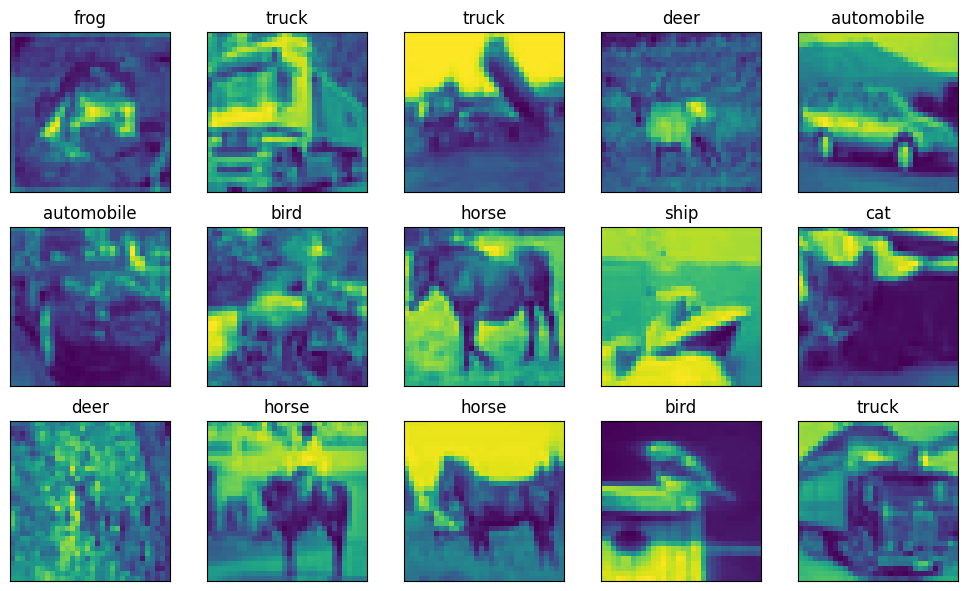

(10000, 32, 32)


In [17]:
#### However the dataset performed very poorly on colored complex dataset, perhaps because many irrelevant features made it hard to classify
## need to think how to get rid of the irrelevant features

### Testing on a different dataset

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train = x_train[:,:,:,-1]#.sum(axis=-1)/x_train.shape[-1]
x_test = x_test[:,:,:,-1]#.sum(axis=-1)/x_test.shape[-1]

# Define the class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

# Plot some sample images
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(10,6))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(class_names[y_train[i][0]])
plt.tight_layout()
plt.show()

print(x_test.shape)

cond = np.where((((y_train==0)|(y_train==1))|(y_train==3)))[0]
sc = x_train#[cond]#*255.0
cs = y_train#[cond]

cond_ = np.where((((y_test==0))|(y_test==1))|(y_test==3))[0]
sc_ = x_test#[cond_]#*255.0
cs_ = y_test#[cond_]

# Normalize the input and output
x_train = sc.reshape(sc.shape[0], -1) / 255.
x_test = sc_.reshape(sc_.shape[0], -1) / 255.

Y_train = to_categorical(cs)
Y_test = to_categorical(cs_)

In [18]:
## Predicting the Classes for the Test Set

filteTest = [np.random.randint(0,x_test.shape[0],100)]
X_test = x_test[filteTest]
y_test = Y_test[filteTest]
y_pred = np.array(KNN_Classify(x_train,Y_train,X_test))

/var/folders/4q/kbjf5khx03n2wv_vdztf96480000gn/T/ipykernel_2010/3620419380.py:4: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  X_test = x_test[filteTest]
/var/folders/4q/kbjf5khx03n2wv_vdztf96480000gn/T/ipykernel_2010/3620419380.py:5: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  y_test = Y_test[filteTest]
/var/folders/4q/kbjf5khx03n2wv_vdztf96480000gn/T/ipykernel_2010/884647241.py:30: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will

treed
4.945929507516725e-12
0 ________________ 0
3.882020156675097e-10
1 ________________ 1
8.44370913182928e-15
2 ________________ 2
1.2637882693084248e-20
3 ________________ 3
3.95903688560798e-22
4 ________________ 4
6.865224769368059e-11
5 ________________ 5
1.8126633290416817e-09
6 ________________ 6
7.847861285168153e-10
7 ________________ 7
6.544843589766282e-21
8 ________________ 8
9.765352645856776e-11
9 ________________ 9
3.573403886718786e-15
10 ________________ 10
8.504858569631251e-13
11 ________________ 11
1.6208204946359146e-16
12 ________________ 12
1.758038164030975e-17
13 ________________ 13
1.9004488874161927e-07
14 ________________ 14
8.197490910381434e-13
15 ________________ 15
1.5621348418353642e-16
16 ________________ 16
4.626434006209266e-13
17 ________________ 17
2.2191398820766265e-16
18 ________________ 18
1.4819299100892296e-12
19 ________________ 19
3.379991941388743e-17
20 ________________ 20
1.7943828534567833e-14
21 ________________ 21
8.708996717582769e

In [19]:
## Checking Accuracy
n = len(y_test)
acc = sum([np.argmax(y_test[i])==np.argmax(y_pred[i]) for i in range(n)])/n
#acc = sum([(y_test[i])==(y_pred[i]) for i in range(n)])/n

ind = np.arange(0,n)
print("The Accuracy for this test set")
acc

The Accuracy for this test set


0.3

# Judging the accuracy

As it is clear the algorithm works great on different classification datasets but it failed on the cifar10 dataset.
The dataset consists of colored elements and also has many irrelevant pixels/data points/dimentions which need to be ignored when looking at the image but they affect the distance function and so the weights leading to incorrect classification.. Need to figure a way to ignore such irrelavant data points and then the accuracy might be better.. Also we need more data in training/density of data points in training so to enhance the accuracy, in general the accuracy increases with higher density of data points in training

# The Conclusion

So most machine learning models or any prediction model works on interpolation data, as a matter these models are only work good on interpolating data, any input outside the domain of training will in general perform worst as compared to any other model. They are not good at extrapolation unless the model actually captures a definite nature of the function variation that can be extended beyond the training domain..

The method mentioned above is kind of like such an interpolation, it extends the function within domain based on closeness to the data points classes nearby so if an input is too close to certain training data point it perhaps belongs to the same class..

An interesting thing to note is the accuracy of the MNIST dataset, it is an handwritten digits images to labels but such high accuracy suggests that all the digits that look the same/are same are in fact close to each other in the higher dimentional space (image shape in this case)..
Moreover all such classification problems have this characteristic of closeness of similar data classes in the input vector space